<h3 style="color:teal;text-align:center">⌞Feature Engineering⌟</h3>

<h4>• Implementation</h4>

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("dataset/aquair_merged_5min.csv", parse_dates=["timestamp(UTC+1)"])
df.set_index("timestamp(UTC+1)", inplace=True)

# 1. Cyclical Time Features
df['hour'] = df.index.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

# 2. Lag Features (based on PACF spikes at Lag 1 & 2)
for lag in [1, 2]:
  df[f'pm25_lag_{lag}'] = df['pm25'].shift(lag)
  df[f'co2_lag_{lag}'] = df['co2'].shift(lag)

# 3. Rolling Statistics
# 6 steps = 30 minutes; 12 steps = 1 hour
df['pm25_rolling_mean_1h'] = df['pm25'].rolling(window=12).mean()
df['temp_rolling_mean_30m'] = df['temp'].rolling(window=6).mean()
df['pm25_volatility_1h'] = df['pm25'].rolling(window=12).std()

# 4. Meteorological Interaction
df['humid_temp_inter'] = df['humid'] * df['temp']

# 5. Define the Target
df['target_pm25_15m'] = df['pm25'].shift(-3)

df_final = df.dropna()
df_final.to_csv("dataset/aquair_final.csv")

<h4>• Verification + EDA</h4>

--- 1. Sine/Cosine Boundary Test ---
     hour_sin  hour_cos
min      -1.0      -1.0
max       1.0       1.0

--- 2. Lag Alignment (Row n should match Row n-1) ---
                           pm25  pm25_lag_1  pm25_lag_2
timestamp(UTC+1)                                       
2024-10-14 13:55:00+01:00   5.3         NaN         NaN
2024-10-14 14:00:00+01:00   8.0         5.3         NaN
2024-10-14 14:05:00+01:00   4.0         8.0         5.3
2024-10-14 14:10:00+01:00   2.8         4.0         8.0
2024-10-14 14:15:00+01:00  13.0         2.8         4.0

--- 3. Null Value Audit ---
score                    1310
temp                     1310
humid                    1310
co2                      1310
voc                      1310
pm25                     1310
pm10                     1310
hour                        0
hour_sin                    0
hour_cos                    0
pm25_lag_1               1311
co2_lag_1                1311
pm25_lag_2               1312
co2_lag_2                

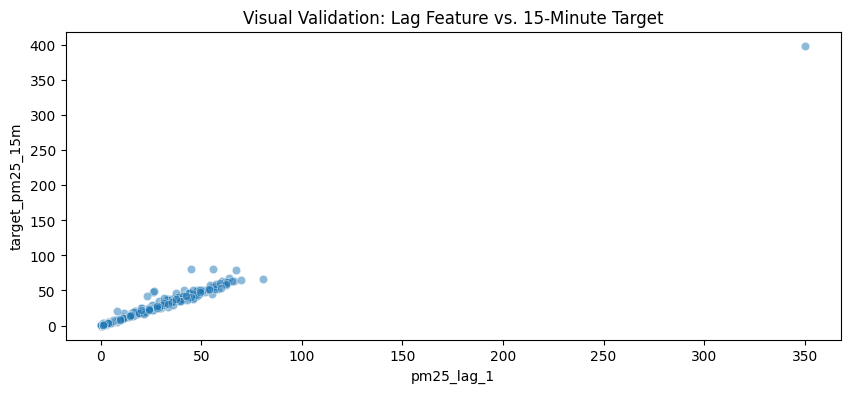

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Summary Statistics for Cyclical Features
# Image 5 showed strong 24h seasonality; sin/cos must be bounded [-1, 1]
temporal_check = df[['hour_sin', 'hour_cos']].describe().loc[['min', 'max']]

# 2. Lag Alignment Check (Manual Verification of 'Memory')
# Image 4 (PACF) showed Lag 1 dependency; check if the shift is correct
lag_alignment = df[['pm25', 'pm25_lag_1', 'pm25_lag_2']].head(5)

# 3. Missing Value Audit
# Feature engineering creates NaNs at the start (lags) and end (target horizon)
null_audit = df.isnull().sum()

# 4. Cross-Lag Correlation (Predictive Strength)
# Image 3 showed CO2/PM2.5 correlation (0.62). 
# Check if previous CO2 is still a strong indicator for current PM2.5
cross_corr = df[['pm25', 'co2_lag_1', 'pm25_lag_1']].corr()

print("--- 1. Sine/Cosine Boundary Test ---")
print(temporal_check)
print("\n--- 2. Lag Alignment (Row n should match Row n-1) ---")
print(lag_alignment)
print("\n--- 3. Null Value Audit ---")
print(null_audit)
print("\n--- 4. Cross-Feature Correlation ---")
print(cross_corr)
print(f"\n--- 5. Final Matrix Shape: {df.shape} ---")

# Visual Sanity Check: Plotting the Target against a Lag
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df.sample(500), x='pm25_lag_1', y='target_pm25_15m', alpha=0.5)
plt.title("Visual Validation: Lag Feature vs. 15-Minute Target")
plt.show()